Examined how runs are distributed across overs in IPL matches

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\acer\AppData\Local\Temp\ipykernel_8476\3080681042.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("ipl_ball_by_ball_clean.csv")


   match_id        date season       city  \
0   1082591  2017-04-05   2017  Hyderabad   
1   1082591  2017-04-05   2017  Hyderabad   
2   1082591  2017-04-05   2017  Hyderabad   
3   1082591  2017-04-05   2017  Hyderabad   
4   1082591  2017-04-05   2017  Hyderabad   

                                       venue                team1  \
0  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   
1  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   
2  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   
3  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   
4  Rajiv Gandhi International Stadium, Uppal  Sunrisers Hyderabad   

                         team2         batting_team  \
0  Royal Challengers Bangalore  Sunrisers Hyderabad   
1  Royal Challengers Bangalore  Sunrisers Hyderabad   
2  Royal Challengers Bangalore  Sunrisers Hyderabad   
3  Royal Challengers Bangalore  Sunrisers Hyderabad   
4  Royal Challengers Bangalore  Sunrise

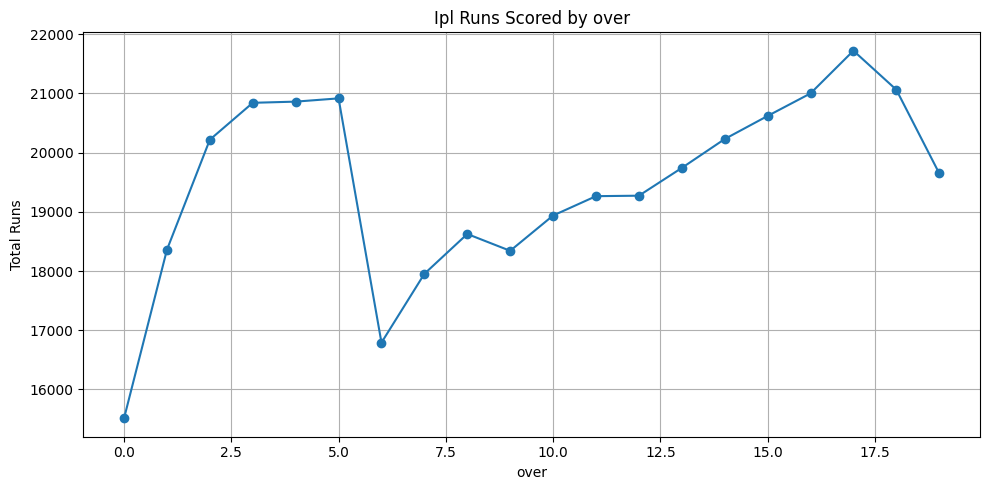

In [9]:
df=pd.read_csv("ipl_ball_by_ball_clean.csv")
print(df.head())
print(df.columns)
over_runs=df.groupby('over')['total_runs'].sum()
plt.figure(figsize=(10,5))
plt.plot(over_runs.index,over_runs,marker='o')
plt.title("Ipl Runs Scored by over")
plt.xlabel("over")
plt.ylabel("Total Runs")
plt.grid(True)
plt.tight_layout()
plt.show()

Explored IPL venue-wise performance and match statistics

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

venue
M Chinnaswamy Stadium                  104
MA Chidambaram Stadium                  95
Rajiv Gandhi International Stadium      87
Eden Gardens                            77
Wankhede Stadium                        73
Feroz Shah Kotla                        60
Wankhede Stadium, Mumbai                57
Sawai Mansingh Stadium                  47
Punjab Cricket Association Stadium      46
Dubai International Cricket Stadium     46
Name: count, dtype: int64


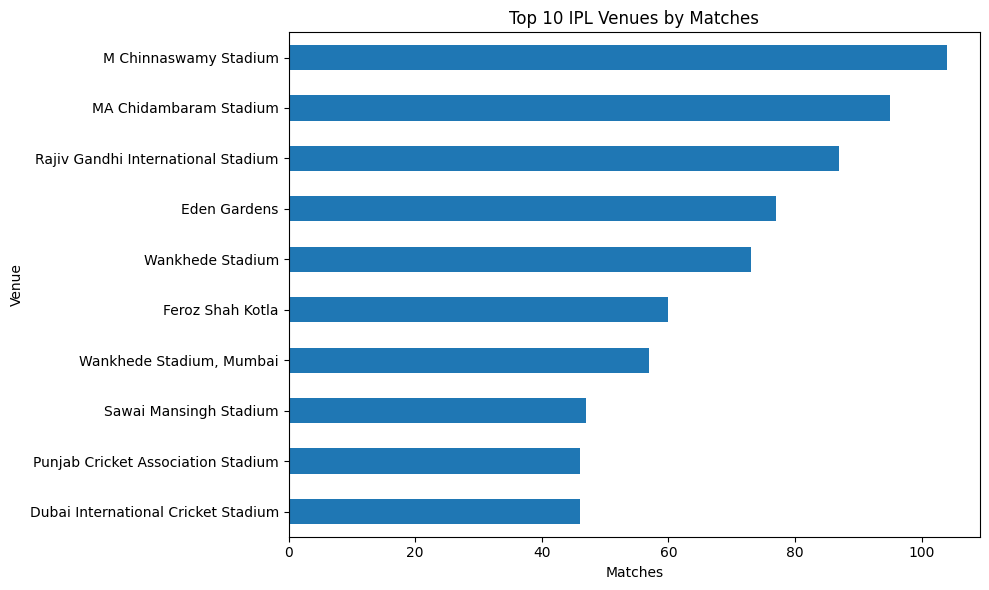

In [30]:
matches = pd.read_csv("ipl_matches_clean.csv")

matches["venue"] = matches["venue"].replace({
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association Stadium",
    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association Stadium",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium"
})

venue_matches = matches["venue"].value_counts().head(10)

print(venue_matches)

plt.figure(figsize=(10,6))
venue_matches.sort_values().plot(kind="barh")
plt.title("Top 10 IPL Venues by Matches")
plt.xlabel("Matches")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()

Examined team-wise match participation in IPL history

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

Mumbai Indians                 285
Delhi Capitals                 276
Punjab Kings                   272
Kolkata Knight Riders          272
Chennai Super Kings            260
Rajasthan Royals               245
Royal Challengers Bangalore    240
Sunrisers Hyderabad            205
Deccan Chargers                 75
Gujarat Titans                  69
Lucknow Super Giants            66
Pune Warriors                   46
Royal Challengers Bengaluru     39
Rising Pune Supergiants         30
Gujarat Lions                   30
Kochi Tuskers Kerala            14
Name: count, dtype: int64


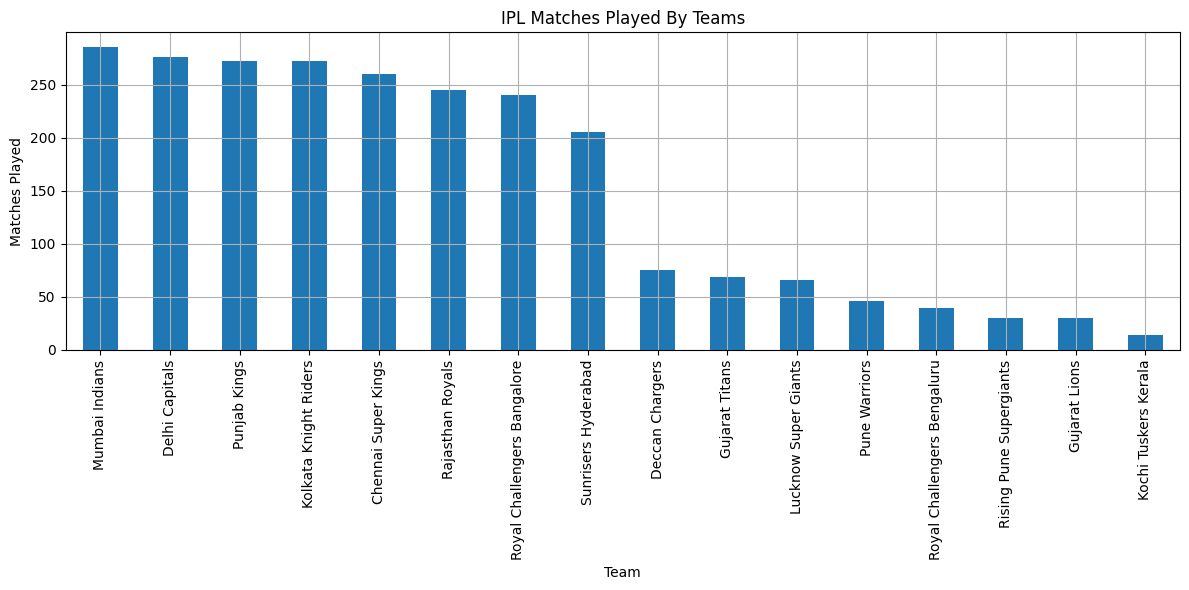

In [27]:
matches = pd.read_csv("ipl_matches_clean.csv")

matches["team1"] = matches["team1"].replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants"
})

matches["team2"] = matches["team2"].replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants"
})

teams = pd.concat([matches["team1"], matches["team2"]])

team_matches = teams.value_counts()

print(team_matches)

plt.figure(figsize=(12,6))
team_matches.plot(kind="bar")
plt.title("IPL Matches Played By Teams")
plt.xlabel("Team")
plt.ylabel("Matches Played")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()



Players who represented more than one IPL team

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("ipl_ball_by_ball_clean.csv")

player_teams = (
    df.groupby("batter")["batting_team"]
    .nunique()
    .reset_index(name="teams_played")
)

team_changers = player_teams[player_teams["teams_played"] > 1]
team_changers = team_changers.sort_values("teams_played", ascending=False)

print(team_changers.head(20))

C:\Users\acer\AppData\Local\Temp\ipykernel_8476\63279288.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ipl_ball_by_ball_clean.csv")


             batter  teams_played
44         AJ Finch             9
51        AM Rahane             7
602       SN Thakur             7
419  Mohammed Shami             7
369      MA Agarwal             7
392       MK Pandey             7
301      KD Karthik             7
261      JD Unadkat             7
557        S Dhawan             6
137       CJ Jordan             6
200    F du Plessis             6
491       Q de Kock             6
166        DJ Hooda             6
545      RV Uthappa             6
308        KL Rahul             6
403        MR Marsh             6
725    Yuvraj Singh             6
217      GJ Maxwell             6
463        PA Patel             6
155       DA Miller             5


Players and their batting teams

In [20]:
player_team_list = (
    df.groupby("batter")["batting_team"]
    .unique()
    .reset_index()
)

print(player_team_list.head(20))

            batter                                       batting_team
0   A Ashish Reddy             [Deccan Chargers, Sunrisers Hyderabad]
1         A Badoni                             [Lucknow Super Giants]
2       A Chandila                                 [Rajasthan Royals]
3         A Chopra                            [Kolkata Knight Riders]
4      A Choudhary                      [Royal Challengers Bangalore]
5      A Dananjaya                                   [Mumbai Indians]
6       A Flintoff                              [Chennai Super Kings]
7         A Kamboj              [Mumbai Indians, Chennai Super Kings]
8         A Kumble                      [Royal Challengers Bangalore]
9        A Manohar              [Gujarat Titans, Sunrisers Hyderabad]
10        A Mhatre                              [Chennai Super Kings]
11        A Mishra  [Delhi Daredevils, Delhi Capitals, Lucknow Sup...
12        A Mithun                      [Royal Challengers Bangalore]
13        A Mukund  

Analyzed which bowlers dismissed each batter in IPL matches

In [21]:
dismissals = df[
    df["wicket_player_out"].notna()
]

batter_bowler = (
    dismissals.groupby(
        ["wicket_player_out", "bowler"]
    )
    .size()
    .reset_index(name="dismissals")
    .sort_values("dismissals", ascending=False)
)

print(batter_bowler.head(20))

      wicket_player_out          bowler  dismissals
7866          RG Sharma       SP Narine           8
5993           MS Dhoni         PP Ojha           7
716           AM Rahane         B Kumar           7
5339         MA Agarwal       YS Chahal           7
3092         GJ Maxwell       RA Jadeja           7
987           AT Rayudu       MM Sharma           7
6029           MS Dhoni          Z Khan           7
7754          RG Sharma        A Mishra           7
8036            RR Pant       JJ Bumrah           7
8223         RV Uthappa        R Ashwin           7
10473           V Kohli  Sandeep Sharma           7
2165          DA Warner        UT Yadav           6
993           AT Rayudu       PP Chawla           6
6693           PA Patel         B Kumar           6
775           AM Rahane        R Ashwin           6
7870          RG Sharma  Sandeep Sharma           6
6971            PP Shaw       DL Chahar           6
2960          G Gambhir          Z Khan           6
6349        

Analyzed the total matches won by each IPL team

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

                           Team  Wins
0                Mumbai Indians   153
1           Chennai Super Kings   145
2         Kolkata Knight Riders   136
3                  Punjab Kings   125
4                Delhi Capitals   122
5              Rajasthan Royals   120
6   Royal Challengers Bangalore   114
7           Sunrisers Hyderabad    99
8                Gujarat Titans    42
9          Lucknow Super Giants    32
10              Deccan Chargers    29
11                    No Result    25
12  Royal Challengers Bengaluru    24
13      Rising Pune Supergiants    15
14                Gujarat Lions    13
15                Pune Warriors    12
16         Kochi Tuskers Kerala     6


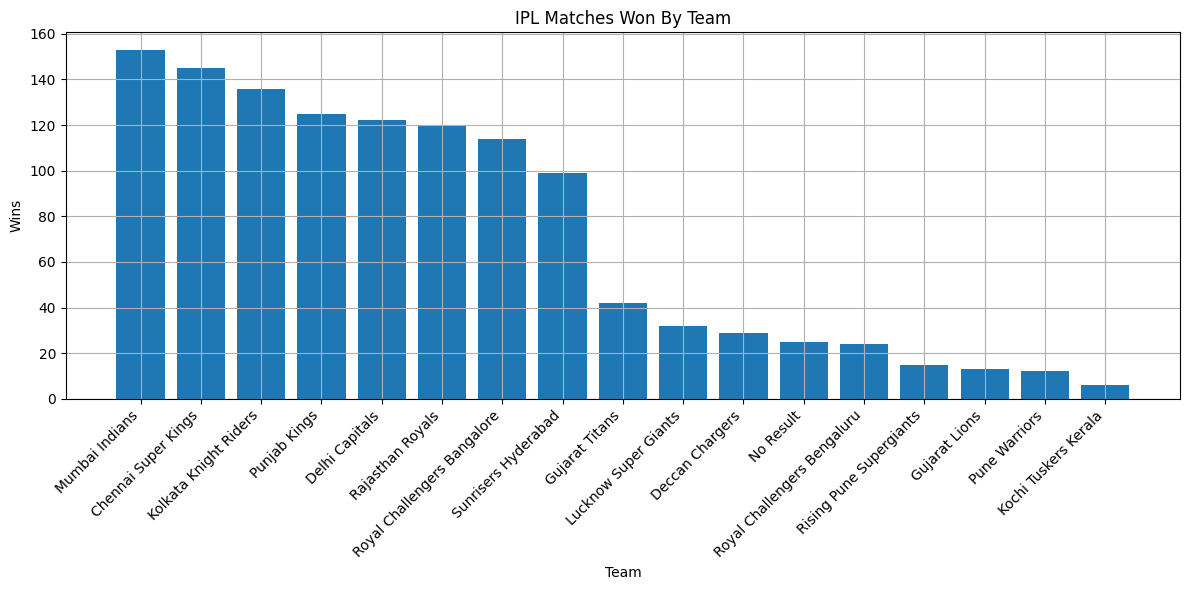

In [24]:
matches = pd.read_csv("ipl_matches_clean.csv")

matches["winner"] = matches["winner"].replace({
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings"
})

team_wins = matches["winner"].value_counts().reset_index()

team_wins.columns = ["Team", "Wins"]

print(team_wins)

plt.figure(figsize=(12,6))
plt.bar(team_wins["Team"], team_wins["Wins"])
plt.title("IPL Matches Won By Team")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()
